# Chapter 4: Designed and Adaptive Search for Failure

Chapter 4 treats the search for weak regions as an optimization problem under a fixed evaluation budget. Candidate tests are constructed, evaluated and retained on a Pareto frontier, and an optimizer uses the measured results to construct further candidates. The chapter's executed case, the error-aware medoid search of Section 4.11.1, applies this loop to the frozen AML predictor: a candidate is a set of four medoids, and its objectives are the selected region's Brier contrast and population share.

This notebook replays that search from its saved records. It accounts for search effort, traces how candidates were constructed, recomputes the frontier by an independent method, reproduces the selections of all nine ordinary runs and rebuilds the chapter's confirmation comparison of twinning and random initialization. A final section redraws the chapter's separate historical experiment on twinning as a train/test split method. No model is fitted and no language model is called.

**Evidence.** The medoid search records are in `book/evidence/aml_medoid_loop_leaf_output_20260921/`, the same historical run used in Chapter 2: 40,000 discovery observations, a fixed 3,000-row medoid pool, three optimizer seeds and 200,000 confirmation observations at seed 62491. The split experiment is in `paper/aml_twinning_splits_20260919/` and uses a different generator. The population is synthetic, and Chapter 3's corrected weighted-leaf geometry belongs to a different run.

**Run order.** Run the cells from top to bottom. Each assertion checks a recomputed quantity against the saved record or against a value printed in the chapter.

## Setup and source checks

Use a Python kernel with the dependencies listed in the README. The setup cell locates the data root, which holds the evidence files and helper modules. It uses `MODEL_VALIDATION_ROOT` when that variable is set. Otherwise it searches for a repository checkout containing the current directory and then for the copy installed with the `aiv` package.

`load()` reads the protocol, confirmation results and frozen finalists and checks the SHA-256 digests that link them to the predictor, auxiliary models and discovery inputs. A failed assertion means a file differs from the recorded run. `RUN` is the evidence directory, and `frontier` is the sorting routine from Chapter 2.

In [1]:
from pathlib import Path
import os
import platform
import sys
import importlib.util

# Locate the data root: the directory whose relative layout the evidence records use.
MARKER = "book/notebooks/regional_case/companion.py"

def find_data_root():
    configured = os.environ.get("MODEL_VALIDATION_ROOT")
    if configured:
        root = Path(configured).expanduser().resolve()
        if not (root / MARKER).is_file():
            raise FileNotFoundError(f"MODEL_VALIDATION_ROOT must contain {MARKER}")
        return root, "MODEL_VALIDATION_ROOT"
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / MARKER).is_file():
            return path, "repository checkout"
    try:
        from aiv.companions import locate
    except ImportError:
        raise FileNotFoundError(
            "Companion data not found. Install the aiv package, open the notebook "
            "inside the repository checkout, or set MODEL_VALIDATION_ROOT.") from None
    return locate()

ROOT, DATA_SOURCE = find_data_root()
HELPERS = ROOT / "book/notebooks/regional_case"
for path in (ROOT, ROOT / "book", HELPERS):
    value = str(path)
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

# Load current helper files even if this kernel cached an older notebook revision.
def load_helper_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module

load_helper_module("companion", HELPERS / "companion.py")
load_helper_module("ch02_helpers", HELPERS / "ch02_helpers.py")
load_helper_module("weighted_leaf_geometry", ROOT / "book/weighted_leaf_geometry.py")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
print("Python:", platform.python_version())
print("Data root found from:", DATA_SOURCE)
from companion import RUN, read, load, frontier, confirmation, measure, assignments
pd.set_option("display.float_format", "{:.6f}".format)
protocol, results, frozen = load()
print("Evidence:", RUN.relative_to(ROOT))
print("Mode: saved-evidence replay; no fitting or live LLM calls")


Python: 3.12.3
Data root found from: repository checkout
Evidence: book/evidence/aml_medoid_loop_leaf_output_20260921
Mode: saved-evidence replay; no fitting or live LLM calls


## Account for search effort

Two searches can be compared only when their cost is measured in the same unit. In this study the evaluator's unit of work is a region score: assigning the discovery sample to one cell of a partition and measuring its Brier contrast. A four-medoid candidate has four cells, so every evaluated candidate is charged four region scores, including cells that fail the support rules (Section 4.11.1).

Three ordinary arms are compared for each optimizer seed. The twinning arm starts from sixteen PAM medoid sets built on twinned subsets of the medoid pool, plus the Chapter 3 subset-PAM set. The random arm replaces the twinned subsets with random subsets of similar size and keeps the same PAM construction and search. The continuation arm resumes the twinning search and spends a second budget of the same size without any structural change; Chapter 5 uses it as the control for structural reflection.

The table reports, for seed 73101, the region-score budget charged by each run, the number of candidate records in its history, the number inherited from an earlier run and the number of distinct medoid sets. The assertions check that continuation's first 400 records are exactly the twinning history.

In [2]:
runs={arm:read(RUN/f"{arm}_73101.json") for arm in ["twinning","random","continuation"]}
display(pd.DataFrame([dict(arm=arm,budget=r["region_score_budget"],
 candidates=len(r["records"]),inherited=r["inherited_candidates"],unique=r["unique_medoids"],
 invalid=sum(not x["valid"] for x in r["records"])) for arm,r in runs.items()]))
assert runs["twinning"]["region_score_budget"]==1600 and len(runs["twinning"]["records"])==400
assert runs["continuation"]["records"][:400]==runs["twinning"]["records"]

,arm,budget,candidates,inherited,unique,invalid
0,twinning,1600,400,0,399,49
1,random,1600,400,0,400,4
2,continuation,1600,800,400,793,107


**Read the output.** The twinning and random runs each evaluate 400 candidates for 1,600 region scores. Continuation's history holds 800 records, of which 400 are inherited, so its own cost is a further 1,600 region scores; comparing its full history with a 400-candidate run would double-count the inherited effort. The distinct-set counts (399, 400 and 793) show that the search rarely re-evaluates a medoid set it has already scored. Invalid candidates, 49 in the twinning run, are charged but cannot enter the frontier because a cell or the selected region failed the support rules.

## Inspect candidate changes

Adaptive search constructs each new candidate from an existing one. The optimizer draws a parent from the current frontier, with selection mass given by fractional ownership of the two objectives plus a 5% uniform component. It then applies a variation operator. A `medoid_replacement` child replaces one or two parent medoids with observed rows, taken either from the parent's leaf-output neighbors or from the whole medoid pool. A `restart` child, drawn with probability 10%, is a fresh random medoid set with no parent. Every child is assigned and scored on the full discovery sample before it can enter the frontier (Section 4.10).

Each record keeps its `id`, `parent_id` and `operation`, so the lineage of any candidate can be traced back to an initial design. The cell counts the operations in the seed-73101 twinning history and displays records 16 to 20, which span the end of the initial designs and the first children.

In [3]:
display(pd.Series([r["operation"] for r in runs["twinning"]["records"]]).value_counts().rename("records"))
display(pd.DataFrame([{k:r[k] for k in ["id","parent_id","operation","medoids"]} for r in runs["twinning"]["records"][16:21]]))

medoid_replacement    339
restart                44
seed                   17
Name: records, dtype: int64

,id,parent_id,operation,medoids
0,16,NaN,seed,"[49, 160, 2099, 2503]"
1,17,7.000000,medoid_replacement,"[269, 404, 2567, 2975]"
2,18,15.000000,medoid_replacement,"[0, 861, 1012, 1964]"
3,19,6.000000,medoid_replacement,"[560, 752, 2688, 2874]"
4,20,19.000000,medoid_replacement,"[320, 560, 2688, 2874]"


**Read the output.** The history contains 17 seed records, 339 medoid replacements and 44 restarts. Records 0 to 16 are the initial designs: record 0 is the Chapter 3 subset-PAM set and records 1 to 16 are the twinning initializations, none of which has a parent. Record 17 is the first child, and its parent is record 7. Record 20 has parent 19, which is itself a child, so lineage can extend over several generations. Pandas displays the missing parent of a seed as NaN.

## Check the frontier

Chapter 2 recomputed the frontier with the sorting routine `frontier`. This cell checks it by a different route. For $n$ valid candidates with objective vectors $v_1,\dots,v_n$, both maximized, candidate $j$ is dominated when some $i$ satisfies $v_i\ge v_j$ in both coordinates and $v_i>v_j$ in at least one. The cell forms this $n\times n$ comparison with array broadcasting, marks each column that some row dominates and takes the remaining objective vectors as the frontier. The assertions require that this pairwise construction, the sorting routine and the frontier saved with the search all identify the same candidates.

The plot places every evaluated candidate by discovery share and discovery contrast and joins the frontier members in order of share.

Valid candidates: 351 Nondominated records: 66 Distinct nondominated objective vectors: 39 Frontier members: 39


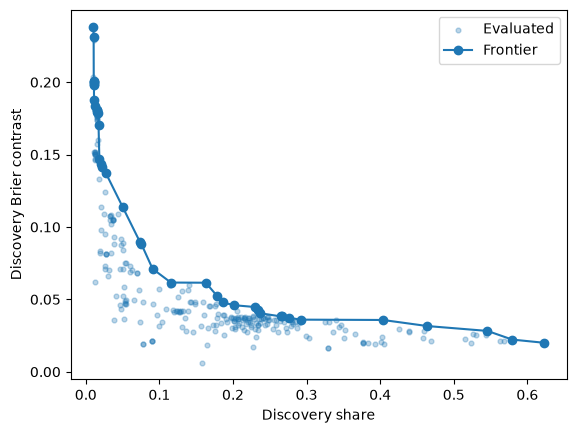

In [4]:
r=runs["twinning"]
valid=[x for x in r["records"] if x["valid"]]
v=np.array([x["objectives"] for x in valid])
dominated=((v[:,None,:]>=v[None,:,:]).all(2)&(v[:,None,:]>v[None,:,:]).any(2)).any(0)
expected={tuple(x) for x in v[~dominated]}
f=frontier(r["records"])
assert {tuple(x["objectives"]) for x in f}==expected
assert {x["id"] for x in f}==set(r["frontier_ids"])
print("Valid candidates:", len(valid), "Nondominated records:", int((~dominated).sum()),
      "Distinct nondominated objective vectors:", len(expected), "Frontier members:", len(f))
plt.scatter(v[:,1],v[:,0],s=12,alpha=.3,label="Evaluated")
plt.plot([x["objectives"][1] for x in f],[x["objectives"][0] for x in f],"o-",label="Frontier")
plt.xlabel("Discovery share");plt.ylabel("Discovery Brier contrast");plt.legend();plt.show()

**Read the output.** The three constructions agree on the frontier's objective vectors. Of the 351 valid candidates, 66 records are nondominated but they share only 39 distinct objective vectors: candidates with identical objectives do not dominate one another, and `frontier` keeps the earliest ID of each, giving the 39 saved frontier members. In 21 of the 22 repeated objective vectors the medoid sets differ, so different medoid sets can yield a selected region with the same size and contrast. The frontier traces the upper envelope of the evaluated candidates: the highest contrasts occur only for regions near the 1% share minimum, and contrast declines as regions widen. Candidates below the envelope are dominated by at least one frontier member. Nondominance is relative to the candidates actually evaluated; it does not certify that a better partition is absent from the unexplored part of the space.

## Reproduce selection

Each run freezes one candidate for confirmation by the policy used in Chapter 2: the largest discovery contrast among frontier members with at least 10% discovery share, with ties broken by share and then by earlier ID. The cell applies this policy to the nine ordinary runs (three arms for each of seeds 73101, 73102 and 73103) and asserts that it reproduces each recorded primary selection. The table reports the selected cell and its discovery measurements. `loss` and `rest_loss` are the regional and remaining mean Brier losses whose difference is `contrast`.

In [5]:
rows=[]
for seed in protocol["seeds"]:
    for arm in ["twinning","random","continuation"]:
        run=read(RUN/f"{arm}_{seed}.json")
        choice=max((x for x in frontier(run["records"]) if x["objectives"][1]>=.10),key=lambda x:(*x["objectives"],-x["id"]))
        assert choice==run["primary"]
        rows.append(dict(seed=seed,arm=arm,discovery_share=choice["objectives"][1],**choice["region"]))
display(pd.DataFrame(rows))
assert read(RUN/"random_73103.json")["primary"]["objectives"][1]==0.1008

,seed,arm,discovery_share,cells,n,share,loss,rest_loss,contrast
0,73101,twinning,0.115625,[0],4625,0.115625,0.075458,0.013842,0.061616
1,73101,random,0.141200,[3],5648,0.141200,0.062623,0.014117,0.048506
2,73101,continuation,0.115625,[0],4625,0.115625,0.075458,0.013842,0.061616
3,73102,twinning,0.124100,[1],4964,0.124100,0.071151,0.013856,0.057295
4,73102,random,0.103050,[2],4122,0.103050,0.079636,0.014226,0.065410
5,73102,continuation,0.100800,[3],4032,0.100800,0.078657,0.014499,0.064158
6,73103,twinning,0.124300,[1],4972,0.124300,0.073995,0.013439,0.060556
7,73103,random,0.100800,[1],4032,0.100800,0.090265,0.013198,0.077067
8,73103,continuation,0.104550,[0],4182,0.104550,0.079685,0.014111,0.065575


**Read the output.** The policy reproduces all nine selections from discovery records alone. At seed 73101, continuation selects the same candidate as twinning (contrast 0.061616, share 0.115625): the additional budget found no eligible candidate with a larger contrast. At seeds 73102 and 73103, continuation selects a different region with a larger discovery contrast than the twinning run. Several selections lie just above the floor, such as the random run at seed 73103 with 10.08% share. The floor governs discovery selection only; confirmation measures the frozen region without altering its membership to restore the floor.

## Compare initializations on fresh data

Discovery contrasts cannot compare the arms fairly, because each was maximized over that arm's own search. The comparison therefore uses the 200,000 confirmation observations drawn with seed 62491 after all selections were frozen. The first table rebuilds the chapter's confirmation table (Table 4.4), including the Chapter 3 subset-PAM partition scored by the same contrast rule. The assertions check each row against the values printed in the chapter.

Within a seed, the twinning and random arms share the discovery sample, the search procedure, the budget and the confirmation sample. Their paired difference in confirmation contrast is estimated on the same confirmation rows, and its standard error uses the difference of the two regions' influence functions. The intervals are Bonferroni simultaneous intervals over the study's 19 claims, as in Chapter 2.

Twinning is intended to make each initial subset represent the medoid pool's covariate distribution. The last table reports the mean energy distance, on standardized covariates, between each initial subset and the full pool, taken from the saved audit. Smaller values indicate closer agreement in distribution.

In [6]:
book_table={  # rows of the chapter's fresh-confirmation table: share (%), regional Brier, contrast
    "pam":(20.349,0.053992,0.041112),
    "twinning_73101":(11.393,0.072584,0.057940),"random_73101":(14.037,0.062941,0.048504),
    "twinning_73102":(12.311,0.068592,0.053993),"random_73102":(10.347,0.080225,0.065786),
    "twinning_73103":(12.313,0.066468,0.051573),"random_73103":(9.896,0.087209,0.073208)}
table=pd.DataFrame({k:dict(share_pct=100*results["confirmation"][k]["share"],brier=results["confirmation"][k]["brier"],
                           contrast=results["confirmation"][k]["contrast"]) for k in book_table}).T
display(table)
for k,(share,brier,contrast) in book_table.items():
    c=results["confirmation"][k]  # Python rounding on the stored floats, as printed in the chapter
    assert (round(100*c["share"],3),round(c["brier"],6),round(c["contrast"],6))==(share,brier,contrast),k
assert round(results["overall_brier"],6)==0.021245
paired=pd.DataFrame([c for c in results["comparisons"] if c["a"]=="twinning"])
paired["simultaneous_ci"]=[[round(x,6) for x in ci] for ci in paired["simultaneous_ci"]]
display(paired[["seed","contrast_difference","simultaneous_ci"]])
assert list(paired["simultaneous_ci"])==[[0.005746,0.013125],[-0.016765,-0.006821],[-0.025933,-0.017338]]
assert [round(x,6) for x in paired["contrast_difference"]]==[0.009436,-0.011793,-0.021636]
assert results["family_size"]==19
energy=pd.DataFrame(read(RUN/"audit.json")["coverage_energy"]).pivot(index="seed",columns="kind",values="mean_energy")
assert [round(x,6) for x in energy["random"]]==[0.025399,0.022035,0.023622] and (energy["twinning"].round(6)==0.010661).all()
display(energy)

,share_pct,brier,contrast
pam,20.348500,0.053992,0.041112
twinning_73101,11.392500,0.072584,0.057940
random_73101,14.037500,0.062941,0.048504
twinning_73102,12.310500,0.068592,0.053993
random_73102,10.347000,0.080225,0.065786
twinning_73103,12.313000,0.066468,0.051573
random_73103,9.895500,0.087209,0.073208


,seed,contrast_difference,simultaneous_ci
0,73101,0.009436,"[0.005746, 0.013125]"
1,73102,-0.011793,"[-0.016765, -0.006821]"
2,73103,-0.021636,"[-0.025933, -0.017338]"


kind,random,twinning
seed,,
73101,0.025399,0.010661
73102,0.022035,0.010661
73103,0.023622,0.010661


**Read the output.** Every searched region has a larger confirmation contrast than the subset-PAM reference, 0.041112, so search over medoids improved on the compactness-based partition under the contrast criterion. The initialization comparison is mixed. Twinning minus random is 0.009436 at seed 73101, where the interval lies above zero. At seeds 73102 and 73103 the differences are −0.011793 and −0.021636, and both intervals lie below zero. The twinning subsets have mean energy distance 0.010661, less than half the random subsets' 0.022035 to 0.025399, so the initial designs covered the pool as intended; better covariate coverage did not by itself yield a stronger weakness region. The selected regions also differ in share, from 9.896% to 14.037%, so a larger contrast can reflect a narrower region. The three seeds share one discovery sample and one confirmation sample, and the intervals condition on the fitted models and frozen searches.

## Historical split-design figure

Twinning has a second use in the chapter: forming a train/test split (Section 4.3.2). That use asks a different question, namely how accurately a test score estimates the fitted model's performance on new data. A split method can reduce the variation of the test score while making it systematically optimistic, so each test score is compared with the same model's loss on an independent reference sample.

This cell reads the separate historical experiment on the earlier balanced AML generator: an 8,000-row pool at seed 90001, thirty repetitions of each split method with 1,600 test rows and a 40,000-row reference sample at seed 90002. The methods are random splitting, twinning on the covariates $X$ and twinning on the joint matrix $(X,y)$. The assertions check the chapter's split table (Table 4.2) and the reported 60.8% variance reduction, computed as $1-(\mathrm{sd}_{\text{twin}}/\mathrm{sd}_{\text{random}})^2$. The figure redraws Figure 4.1 from the saved records; the book's figure file is built separately by `paper/plot_aml_four_optimizers.py`, and this cell writes nothing.

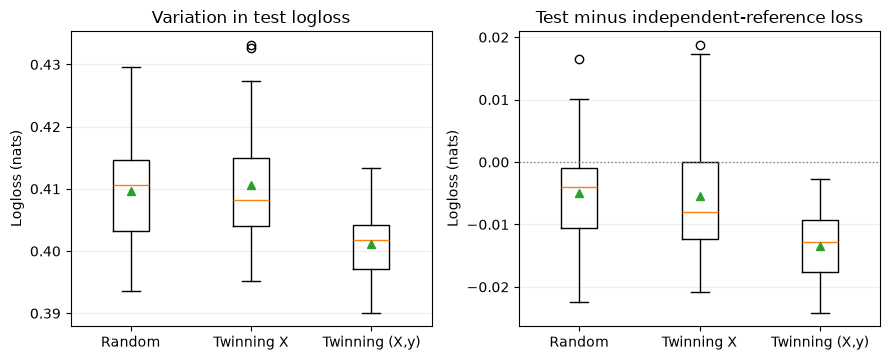

Covariate-only twinning demonstration (separate historical draw, seed 82001):
observed rows: 8000; selected rows: 1600
twinning full energy: 0.000740
random full energy, mean: 0.002431
random full energy, range: [0.001956, 0.003007]



In [7]:
splits=read(ROOT/"paper/aml_twinning_splits_20260919/results.json")
methods=["random","twin_x","twin_xy"];names=["Random","Twinning X","Twinning (X,y)"]
book_split={"random":(0.409710,0.009278,0.414697,0.010598),"twin_x":(0.410566,0.009828,0.416003,0.010986),
            "twin_xy":(0.401097,0.005809,0.414592,0.014495)}  # the chapter's split table
for m,row in book_split.items():
    s=splits["summary"][m]
    assert tuple(round(x,6) for x in (s["test_logloss"]["mean"],s["test_logloss"]["sd"],s["reference_logloss"]["mean"],s["estimation_rmse"]))==row,m
reduction=1-(splits["summary"]["twin_xy"]["test_logloss"]["sd"]/splits["summary"]["random"]["test_logloss"]["sd"])**2
assert round(100*reduction,1)==60.8
assert [round(splits["summary"][m]["test_minus_reference"]["mean"],6) for m in ["twin_xy","random"]]==[-0.013496,-0.004987]
fig,axes=plt.subplots(1,2,figsize=(9,3.7))
for ax,field,title in zip(axes,["test_logloss","test_minus_reference"],["Variation in test logloss","Test minus independent-reference loss"]):
    values=[[a[field] for a in splits["records"] if a["method"]==m] for m in methods]
    ax.boxplot(values,tick_labels=names,showmeans=True);ax.set_title(title);ax.set_ylabel("Logloss (nats)");ax.grid(axis="y",alpha=.2)
axes[1].axhline(0,color="gray",ls=":",lw=1)
fig.tight_layout();plt.show()
print("Covariate-only twinning demonstration (separate historical draw, seed 82001):")
print((ROOT/"book/evidence/twinning/output.txt").read_text())

**Read the output.** The left panel shows that joint twinning narrows the spread of test logloss; its variance is 60.8% below that of random splitting. The right panel shows the cost: its mean test-minus-reference difference is −0.013496, against −0.004987 for random splits, so its test scores understate the reference loss by more. Its estimation RMSE in the table is correspondingly larger. Lower variance and lower observed test loss therefore do not establish a more accurate estimate of generalization performance. The printed demonstration from a separate draw shows that covariate-only twinning does select a subset closer in energy distance to the pool than random subsets do (0.000740 against a random mean of 0.002431). Distributional agreement in the covariates is what twinning optimizes; its effect on a test-score estimate has to be measured for the learner in question.

## What the replay establishes

The ordinary search has been replayed without fitting a model or calling a language model. Its cost was accounted in region scores, its candidates were traced through their lineage, its frontiers were recomputed by two methods and its nine primary selections were reproduced from discovery records. On fresh observations, every searched region exceeds the subset-PAM reference in contrast, while twinning and random initialization each produce the larger contrast at some seeds.

Search has so far moved medoids within a fixed representation (the 120 per-tree leaf outputs) under a fixed region rule that selects a single cell. Chapter 5 asks whether changing that structure, through a proposed derived feature or a union of cells, finds weaker regions than spending the same budget on continuation.


## What to try

1. **Frontiers of the two arms.** Plot the random and twinning frontiers for seed 73101 on the same axes. Identify the share ranges in which each arm has the higher contrast, using discovery records only.
2. **Effort and distinct evaluations.** Count repeated medoid sets in each history by comparing sorted medoid tuples. Explain why the region-score budget, rather than the number of distinct sets, is the cost measure.
3. **Lineage.** Starting from the primary selection of the seed-73101 twinning run, follow `parent_id` back to its initial design and report the operations along the path.
4. **Budget and continuation.** Using the `trace` field of the continuation run, report the largest discovery contrast after 1,600 and after 3,200 region scores. Explain why a larger discovery contrast after further search does not by itself predict a larger confirmation contrast.
